# KMeans + SelectKBest Feature Selection
**ShipmentSure — Predicting On-Time Delivery**

- KMeans clustering to segment shipment profiles into natural operational groups
- SelectKBest to identify top supervised features alongside unsupervised cluster exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 11)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,C,Flight,2,5,306,6,high,M,45,3838,1
1,F,Ship,7,2,114,3,high,M,35,2710,1
2,B,Ship,7,2,215,7,medium,F,44,4152,0
3,A,Road,5,3,126,5,medium,M,54,2245,0
4,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# Use numeric features for clustering
num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

X_num = df[num_cols]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)
print("Features scaled.")

Features scaled.


S:\C\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
S:\C\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
S:\C\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
S:\C\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

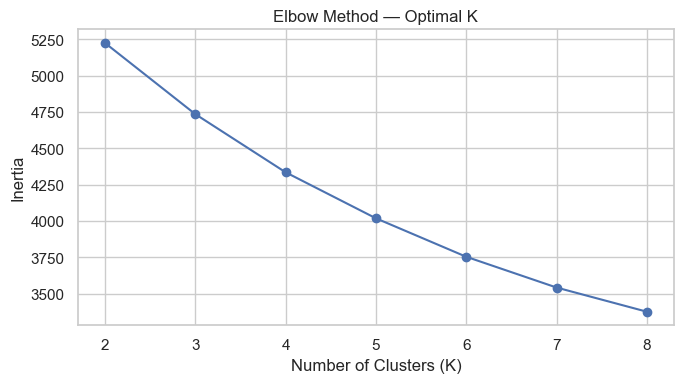

In [4]:
# Elbow method to find optimal K
inertia = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.tight_layout()
plt.show()

In [5]:
# KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['Cluster'].value_counts())

Cluster distribution:
Cluster
1    376
2    324
0    300
Name: count, dtype: int64


S:\C\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [6]:
# Cluster profile — mean values per cluster
cluster_profile = df.groupby('Cluster')[num_cols + ['Reached.on.Time_Y.N']].mean().round(3)
print("Cluster profiles (mean values):")
cluster_profile

Cluster profiles (mean values):


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Cluster,,,,,,,
0,4.687,3.250,189.980,5.723,20.150,2149.203,0.457
1,4.566,2.824,225.747,6.162,50.226,3473.330,0.527
2,4.321,2.914,180.373,6.019,21.781,4786.049,0.525


C:\Users\rishi\AppData\Local\Temp\ipykernel_22372\56534485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


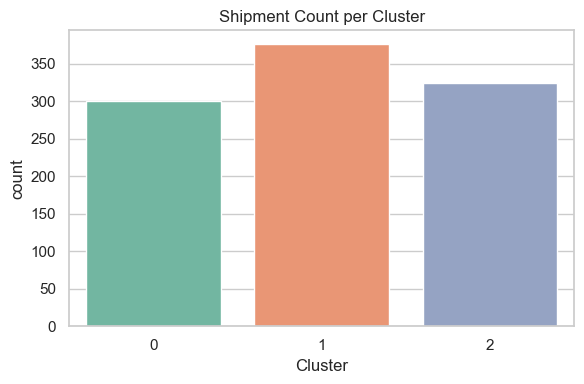

In [7]:
# Cluster count plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title('Shipment Count per Cluster')
plt.tight_layout()
plt.show()

In [8]:
# SelectKBest — supervised feature selection (k=5)
df_encoded = pd.get_dummies(df.drop('Cluster', axis=1), drop_first=True)
X = df_encoded.drop('Reached.on.Time_Y.N', axis=1)
y = df_encoded['Reached.on.Time_Y.N']

selector = SelectKBest(f_classif, k=5)
selector.fit(X, y)

selected_features = X.columns[selector.get_support()]
print("Top 5 supervised features (SelectKBest):")
for feat, score in zip(selected_features, selector.scores_[selector.get_support()]):
    print(f"  {feat}: F-score = {score:.2f}")

Top 5 supervised features (SelectKBest):
  Customer_care_calls: F-score = 1.21
  Weight_in_gms: F-score = 3.25
  Warehouse_block_F: F-score = 1.62
  Mode_of_Shipment_Ship: F-score = 1.74
  Product_importance_medium: F-score = 1.87
